# Deep Momentum v3 -- Research Notebook

Implementation of the Han (2022) + Han & Qin (2025) **Deep Momentum** idea on the S&P 1500 universe, with v3 enhancements.

## The thesis
Past winners have **bimodal** forward return distributions. A classifier that picks the argmax class throws away uncertainty. Deep Momentum predicts the **full probability distribution** over return deciles, ranks stocks by probability-weighted expected return, and avoids the famous momentum crashes.

## v3 enhancements (all five)
1. **Ensemble of XGBoost seeds** (`N_SEEDS=3`) -- averaging probabilities reduces model-noise and typically lifts IC 10-20%
2. **Multi-horizon labels** (1M + 3M) -- train two models, blend their signals by rank
3. **Longer holding period** -- run both 1M- and 3M-hold portfolio variants; 3M hold cuts turnover ~60-70%
4. **Daily-bar features** -- 63d / 252d realized vol, 63d downside vol, 252d intramonth max-drawdown (richer than monthly-derived vols)
5. **Fundamentals** (trailing PE, P/B, ROA, ROE, profit margin, earnings growth) pulled from yfinance

## Honest caveat on fundamentals
yfinance only provides a **current snapshot** (not point-in-time quarterly). We include them as **static cross-sectional features** (constant per ticker across all historical dates). This is **partial look-ahead** -- today's "quality" label leaks into the past. Because XGBoost sees these features as ticker-constants, the practical leakage is bounded (it can't distinguish year-by-year effects), but the feature importance should be monitored. In live trading the look-ahead disappears because "today" really is today.

## Pipeline
1. Load S&P 1500 tickers, monthly prices, daily prices (both cached), and fundamentals snapshot (cached)
2. Build combined feature panel: momentum z-scores + daily-vol features + size/sector dummies + fundamental statics
3. Build 1M and 3M forward-decile labels
4. Hyperparameter grid search (on 1M labels)
5. Walk-forward ensemble training for **each** horizon (1M, 3M)
6. Compute E[R], Sharpe-score, and blended 1M/3M rank score
7. Backtest all variants x (1M hold, 3M hold) x (LO, LS) x (global, sector-neutral)
8. Bimodality diagnostics, calibration, feature importance
9. Live picks enriched with fundamentals

In [1]:
import os, sys, time, warnings, itertools
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import xgboost as xgb
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# ---------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------
UNIVERSE_CSV        = "../../../universe.csv"
CACHE_MONTHLY       = Path("../../../.cache/deep_momentum_prices.pkl")
CACHE_DAILY         = Path("../../../.cache/deep_momentum_daily.pkl")
CACHE_FUNDAMENTALS  = Path("../../../.cache/deep_momentum_fundamentals.pkl")
START_DATE          = "2004-01-01"
END_DATE            = None

FEATURE_MONTHS      = [1, 3, 6, 9, 12]
N_DECILES           = 10
TRAIN_MIN_YEARS     = 5
TOP_PCT             = 0.10
BOTTOM_PCT          = 0.10
TCOST_BPS           = 10
MIN_OBS_PER_MONTH   = 200
RANDOM_SEED         = 42
LIQUIDITY_DROP_PCT  = 0.10

# v3 knobs
N_SEEDS             = 3                 # ensemble members per fold (per horizon)
LABEL_HORIZONS      = [1, 3]            # months; we train a model per horizon
HOLDING_MONTHS_LIST = [1, 3]            # backtest both 1M and 3M holds
VAL_START_YEAR      = 2013
VAL_END_YEAR        = 2014
HYPEROPT_GRID       = {
    "max_depth":     [4, 6],
    "learning_rate": [0.05, 0.10],
    "n_estimators":  [300, 500],
}

for p in [CACHE_MONTHLY, CACHE_DAILY, CACHE_FUNDAMENTALS]:
    p.parent.mkdir(parents=True, exist_ok=True)

print("xgboost", xgb.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)

/Users/shazilfarukh/Desktop/algo_trading/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


xgboost 2.1.3 | pandas 2.3.3 | numpy 2.0.2


## 1. Universe & monthly prices (cached)

In [2]:
def load_universe(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["Symbol"] = df["Symbol"].astype(str).str.strip().str.upper()
    df = df.drop_duplicates(subset="Symbol")
    df = df[df["Symbol"].ne("") & df["Symbol"].ne("NAN")]
    return df

def fetch_yf_panel(symbols, start, end, interval, batch=150) -> dict:
    """Download (Close, Volume) for each symbol at the given interval."""
    out = {}
    kwargs = dict(start=start, interval=interval, auto_adjust=True,
                  progress=False, threads=True, group_by="ticker")
    if end is not None:
        kwargs["end"] = end
    resample_rule = "M" if interval == "1mo" else None
    for i in range(0, len(symbols), batch):
        chunk = symbols[i:i+batch]
        try:
            data = yf.download(chunk, **kwargs)
        except Exception as e:
            print(f"  batch {i//batch} failed: {e}"); continue
        for s in chunk:
            try:
                sub = data[s] if len(chunk) > 1 else data
                df = sub[["Close", "Volume"]].dropna(how="all")
                if df.empty: continue
                if resample_rule:
                    df.index = pd.to_datetime(df.index).to_period("M").to_timestamp("M")
                df = df[~df.index.duplicated(keep="last")]
                out[s] = df
            except Exception:
                continue
        print(f"  {interval} batch {i//batch + 1}/{(len(symbols)-1)//batch + 1}: kept {len(out)} so far")
    return out

UNIVERSE_DF = load_universe(UNIVERSE_CSV)
SYMBOLS     = sorted(UNIVERSE_DF["Symbol"].tolist())
SECTOR_MAP  = UNIVERSE_DF.set_index("Symbol")["Sector"].to_dict()
print(f"Universe: {len(SYMBOLS)} tickers across {UNIVERSE_DF['Sector'].nunique()} GICS sectors")

if CACHE_MONTHLY.exists():
    prices_dict = pd.read_pickle(CACHE_MONTHLY)
    print(f"Loaded cached monthly prices for {len(prices_dict)} symbols")
else:
    print("Downloading monthly bars...")
    t0 = time.time()
    prices_dict = fetch_yf_panel(SYMBOLS, START_DATE, END_DATE, "1mo")
    pd.to_pickle(prices_dict, CACHE_MONTHLY)
    print(f"  {len(prices_dict)} symbols in {time.time()-t0:.0f}s -> cached")

close = pd.concat({s: d["Close"] for s, d in prices_dict.items()}, axis=1).sort_index()
vol   = pd.concat({s: d["Volume"] for s, d in prices_dict.items()}, axis=1).sort_index()
dv    = close * vol
close = close[close.index >= pd.Timestamp(START_DATE)]
dv    = dv.reindex(close.index)
print(f"Monthly panel: {close.shape[0]} months x {close.shape[1]} tickers")

Universe: 1392 tickers across 11 GICS sectors
Loaded cached monthly prices for 1388 symbols


Monthly panel: 268 months x 1388 tickers


## 2. Daily bars (cached) -> daily-derived volatility features

We compute four daily-derived features per (month, stock):
- `vol_daily_63d` -- std of daily returns over last 63 trading days (~3M), annualized
- `vol_daily_252d` -- std over last 252 trading days (~1Y), annualized
- `downside_vol_63d` -- std of NEGATIVE daily returns only (downside semideviation)
- `intramonth_maxdd_252d` -- max drawdown computed on daily peaks over last 252 days

Daily-derived vols are typically lower-noise than monthly-derived vols and capture within-month spikes that monthly closes miss.

In [3]:
if CACHE_DAILY.exists():
    daily_dict = pd.read_pickle(CACHE_DAILY)
    print(f"Loaded cached daily prices for {len(daily_dict)} symbols")
else:
    print("Downloading daily bars (one-time, ~5-10 min)...")
    t0 = time.time()
    daily_dict = fetch_yf_panel(SYMBOLS, START_DATE, END_DATE, "1d")
    pd.to_pickle(daily_dict, CACHE_DAILY)
    print(f"  {len(daily_dict)} symbols in {time.time()-t0:.0f}s -> cached")

# Compute daily-derived features per ticker, then stack to monthly panels
def daily_features_for_ticker(df: pd.DataFrame) -> pd.DataFrame:
    """Given daily (Close, Volume), return monthly-indexed DataFrame of daily-derived features."""
    c = df["Close"].dropna()
    if len(c) < 30:
        return pd.DataFrame()
    r = np.log(c).diff()
    vol_63  = r.rolling(63,  min_periods=30).std()  * np.sqrt(252)
    vol_252 = r.rolling(252, min_periods=120).std() * np.sqrt(252)
    # Downside semideviation
    r_neg = r.where(r < 0, 0)
    dv_63 = r_neg.rolling(63, min_periods=30).std() * np.sqrt(252)
    # Rolling 252d max drawdown (at daily resolution)
    roll_max = c.rolling(252, min_periods=120).max()
    dd = (c / roll_max - 1).rolling(252, min_periods=120).min()
    out = pd.DataFrame({
        "vol_daily_63d":       vol_63,
        "vol_daily_252d":      vol_252,
        "downside_vol_63d":    dv_63,
        "intramonth_maxdd_252d": dd,
    })
    # Resample to month-end, taking last value of each month
    out.index = pd.to_datetime(out.index)
    out = out.resample("M").last()
    return out

t0 = time.time()
daily_feat_dict = {}
for s, d in daily_dict.items():
    fd = daily_features_for_ticker(d)
    if not fd.empty:
        daily_feat_dict[s] = fd
print(f"Computed daily-derived monthly features for {len(daily_feat_dict)} tickers in {time.time()-t0:.0f}s")

# Free the daily dict since we have features now
del daily_dict

# Stack to wide panels: (date x ticker) for each daily-derived feature
DAILY_PANELS = {}
for feat in ["vol_daily_63d", "vol_daily_252d", "downside_vol_63d", "intramonth_maxdd_252d"]:
    DAILY_PANELS[feat] = pd.concat({s: d[feat] for s, d in daily_feat_dict.items()}, axis=1).sort_index()
print(f"Daily-derived feature panels:")
for k, v in DAILY_PANELS.items():
    print(f"  {k}: {v.shape}")


10 Failed downloads:


['ASTH', 'ALL', 'AEO', 'AROC', 'APTV', 'AMT', 'AAP', 'AKAM', 'ADMA', 'AZTA']: TypeError("'NoneType' object is not subscriptable")


  1d batch 1/10: kept 140 so far


  1d batch 2/10: kept 290 so far


$DVAX: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-04-17) (Yahoo error = "No data found, symbol may be delisted")


...

  1d batch 9/10: kept 1308 so far


  1d batch 10/10: kept 1350 so far


  1350 symbols in 273s -> cached


Computed daily-derived monthly features for 1350 tickers in 7s


Daily-derived feature panels:
  vol_daily_63d: (268, 1350)
  vol_daily_252d: (268, 1350)
  downside_vol_63d: (268, 1350)
  intramonth_maxdd_252d: (268, 1350)


## 3. Fundamentals snapshot (cached)

We fetch each ticker's current fundamental ratios via `yf.Ticker(s).info`. **Static, non-PIT**. Fields:
- `trailingPE` (P/E on trailing 12M earnings)
- `priceToBook`
- `returnOnAssets`
- `returnOnEquity`
- `profitMargins`
- `earningsGrowth` (YoY)
- `revenueGrowth`

Cached so this only runs once. Uses a thread pool to keep it to ~3-5 minutes on a fresh cache.

In [4]:
FUND_FIELDS = ["trailingPE", "priceToBook", "returnOnAssets", "returnOnEquity",
               "profitMargins", "earningsGrowth", "revenueGrowth"]

def fetch_info_one(sym: str) -> dict:
    try:
        info = yf.Ticker(sym).info
        return {"Symbol": sym, **{f: info.get(f) for f in FUND_FIELDS}}
    except Exception:
        return {"Symbol": sym, **{f: None for f in FUND_FIELDS}}

def fetch_fundamentals(symbols, cache_path: Path, max_workers: int = 12) -> pd.DataFrame:
    if cache_path.exists():
        df = pd.read_pickle(cache_path)
        print(f"Loaded cached fundamentals for {len(df)} tickers")
        return df
    print(f"Fetching fundamentals via yfinance for {len(symbols)} tickers (one-time)...")
    t0 = time.time()
    rows = []
    done = 0
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(fetch_info_one, s): s for s in symbols}
        for fut in as_completed(futs):
            rows.append(fut.result())
            done += 1
            if done % 200 == 0:
                print(f"  {done}/{len(symbols)} fetched in {time.time()-t0:.0f}s")
    df = pd.DataFrame(rows).set_index("Symbol")
    df = df.apply(pd.to_numeric, errors="coerce")
    pd.to_pickle(df, cache_path)
    print(f"  done in {time.time()-t0:.0f}s; cached to {cache_path}")
    return df

FUND = fetch_fundamentals(SYMBOLS, CACHE_FUNDAMENTALS)
print(f"\nFundamentals coverage per field (non-null %):")
print((FUND.notna().mean() * 100).round(1).to_string())
print("\nSample:")
print(FUND.head())

Fetching fundamentals via yfinance for 1392 tickers (one-time)...


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}


  200/1392 fetched in 4s


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DVAX"}}}


  400/1392 fetched in 9s


...

HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"User is unable to access this feature - https://bit.ly/yahoo-finance-api-feedback"}}}


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}


  done in 26s; cached to ../../../.cache/deep_momentum_fundamentals.pkl

Fundamentals coverage per field (non-null %):
trailingPE       59.0000
priceToBook      66.1000
returnOnAssets   65.2000
returnOnEquity   62.8000
profitMargins    65.7000
earningsGrowth   52.3000
revenueGrowth    65.4000

Sample:
        trailingPE  priceToBook  returnOnAssets  returnOnEquity  \
Symbol                                                            
ABCB       14.2133       1.4184          0.0153          0.1053   
AAL        75.1765      -2.2644          0.0171             NaN   
AA         15.0160       2.8220             NaN             NaN   
ABG         8.4172       1.0447          0.0570          0.1331   
AAON       71.1970       8.5779          0.0645          0.1251   

        profitMargins  earningsGrowth  revenueGrowth  
Symbol                                                
ABCB           0.3620          0.1690         0.0300  
AAL            0.0020         -0.8310         0.0250  
AA     

## 4. Feature engineering (momentum + monthly vol + daily vol + size + sector + fundamentals)

In [5]:
def _xs_zscore(df: pd.DataFrame) -> pd.DataFrame:
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1), axis=0)

def build_features(close: pd.DataFrame, dv: pd.DataFrame, daily_panels: dict,
                   sector_map: dict, fund_df: pd.DataFrame,
                   months=FEATURE_MONTHS, liq_drop_pct: float = LIQUIDITY_DROP_PCT) -> pd.DataFrame:
    log_close = np.log(close)
    monthly_ret = log_close.diff()
    feats = {}

    # Momentum (z-scored)
    for m in months:
        feats[f"ret_{m}m"] = _xs_zscore(log_close - log_close.shift(m))
    # Monthly vol / skew / maxdd / 52W-high
    feats["vol_m_3"]  = _xs_zscore(monthly_ret.rolling(3,  min_periods=3 ).std())
    feats["vol_m_12"] = _xs_zscore(monthly_ret.rolling(12, min_periods=9 ).std())
    feats["skew_12m"] = _xs_zscore(monthly_ret.rolling(12, min_periods=9).skew())
    def _roll_maxdd(series, window=12):
        levels = np.exp(series.cumsum())
        peak = levels.rolling(window, min_periods=6).max()
        return levels / peak - 1
    feats["maxdd_m_12"] = _xs_zscore(monthly_ret.apply(_roll_maxdd, axis=0))
    roll_max = close.rolling(12, min_periods=6).max()
    feats["high_52w_ratio"] = close / roll_max

    # Daily-derived (z-scored cross-sectionally each month)
    # reindex each daily panel to the monthly panel's dates+tickers
    for name, panel in daily_panels.items():
        panel = panel.reindex(index=close.index, columns=close.columns)
        feats[name] = _xs_zscore(panel)

    # Size terciles (trailing 12M dv)
    dv_trail = dv.rolling(12, min_periods=6).mean()
    rank_pct = dv_trail.rank(axis=1, pct=True)
    feats["size_small"] = (rank_pct <= 1/3).astype(float).where(dv_trail.notna())
    feats["size_mid"]   = ((rank_pct > 1/3) & (rank_pct <= 2/3)).astype(float).where(dv_trail.notna())
    feats["size_large"] = (rank_pct > 2/3).astype(float).where(dv_trail.notna())

    # Stack to long format
    long = pd.concat({k: v.stack(dropna=False) for k, v in feats.items()}, axis=1)
    long.index.names = ["date", "symbol"]

    # Liquidity filter
    dv_long = dv_trail.stack(dropna=False).rename("dv_trail")
    dv_long.index.names = ["date", "symbol"]
    long = long.join(dv_long)
    liq_cut = long.groupby(level="date")["dv_trail"].transform(lambda s: s.quantile(liq_drop_pct))
    long = long[long["dv_trail"] >= liq_cut].drop(columns=["dv_trail"])

    # Sector one-hot
    syms = long.index.get_level_values("symbol")
    sec_series = pd.Series(syms.map(sector_map).fillna("Unknown").values, index=long.index, name="sector")
    sec_dummies = pd.get_dummies(sec_series, prefix="sec").astype(float)
    long = pd.concat([long, sec_dummies], axis=1)
    long["__sector__"] = sec_series.values

    # --- Fundamentals (STATIC snapshot per ticker, broadcast to every date) ---
    # Winsorize at 1st/99th percentile to reduce outlier influence
    fund_clipped = fund_df.copy()
    for col in fund_clipped.columns:
        lo, hi = fund_clipped[col].quantile([0.01, 0.99])
        fund_clipped[col] = fund_clipped[col].clip(lower=lo, upper=hi)
    # Z-score cross-sectionally (across tickers)
    fund_z = (fund_clipped - fund_clipped.mean()) / fund_clipped.std()
    fund_z = fund_z.add_prefix("fund_")
    # Broadcast to every (date, symbol)
    fund_by_sym = fund_z.reindex(syms).set_index(long.index)
    long = pd.concat([long, fund_by_sym], axis=1)

    # Drop rows where non-sector, non-fundamental features are missing.
    # We KEEP rows with NaN fundamentals; XGBoost handles missing natively.
    core_cols = [c for c in long.columns
                 if c != "__sector__" and not c.startswith("fund_")]
    return long.dropna(subset=core_cols)

X_ALL = build_features(close, dv, DAILY_PANELS, SECTOR_MAP, FUND)
SECTOR_COL = X_ALL["__sector__"].copy()
X = X_ALL.drop(columns=["__sector__"])
print(f"Feature matrix: {X.shape[0]:,} (date,symbol) rows, {X.shape[1]} features")
print(f"Feature columns: {list(X.columns)}")
print(f"\nFundamentals NaN % per feature (expected to be non-zero -- XGBoost handles NaN):")
print((X[[c for c in X.columns if c.startswith('fund_')]].isna().mean()*100).round(1).to_string())

Feature matrix: 256,114 (date,symbol) rows, 35 features
Feature columns: ['ret_1m', 'ret_3m', 'ret_6m', 'ret_9m', 'ret_12m', 'vol_m_3', 'vol_m_12', 'skew_12m', 'maxdd_m_12', 'high_52w_ratio', 'vol_daily_63d', 'vol_daily_252d', 'downside_vol_63d', 'intramonth_maxdd_252d', 'size_small', 'size_mid', 'size_large', 'sec_Communication Services', 'sec_Consumer Discretionary', 'sec_Consumer Staples', 'sec_Energy', 'sec_Financials', 'sec_Health Care', 'sec_Industrials', 'sec_Information Technology', 'sec_Materials', 'sec_Real Estate', 'sec_Utilities', 'fund_trailingPE', 'fund_priceToBook', 'fund_returnOnAssets', 'fund_returnOnEquity', 'fund_profitMargins', 'fund_earningsGrowth', 'fund_revenueGrowth']

Fundamentals NaN % per feature (expected to be non-zero -- XGBoost handles NaN):
fund_trailingPE       40.8000
fund_priceToBook      34.3000
fund_returnOnAssets   35.3000
fund_returnOnEquity   37.6000
fund_profitMargins    34.8000
fund_earningsGrowth   47.2000
fund_revenueGrowth    35.0000


## 5. Multi-horizon labels (1M and 3M forward deciles)

In [6]:
def build_labels_for_horizon(close: pd.DataFrame, horizon_months: int,
                             n_deciles=N_DECILES, min_obs=MIN_OBS_PER_MONTH) -> pd.DataFrame:
    fwd = np.log(close.shift(-horizon_months)) - np.log(close)
    long = fwd.stack(dropna=False).rename("fwd_ret").reset_index()
    long.columns = ["date", "symbol", "fwd_ret"]
    long = long.dropna(subset=["fwd_ret"])
    def _qcut(s):
        if len(s) < min_obs: return pd.Series(np.nan, index=s.index)
        try:   return pd.qcut(s.rank(method="first"), n_deciles, labels=False)
        except ValueError: return pd.Series(np.nan, index=s.index)
    long["decile"] = long.groupby("date")["fwd_ret"].transform(_qcut)
    long = long.dropna(subset=["decile"]).copy()
    long["decile"] = long["decile"].astype(int)
    return long.set_index(["date", "symbol"])

Y_BY_H = {h: build_labels_for_horizon(close, h) for h in LABEL_HORIZONS}
for h, y in Y_BY_H.items():
    print(f"  horizon={h}M  labels rows={len(y):,}")

# Join X with each label set -- kept as separate DATA_H dicts for each horizon
DATA_BY_H = {}
for h, Y in Y_BY_H.items():
    D = X.join(Y, how="inner").sort_index()
    D["__sector__"] = SECTOR_COL.reindex(D.index).values
    DATA_BY_H[h] = D
    print(f"  DATA (h={h}M) joined: {len(D):,} rows")

  horizon=1M  labels rows=308,276
  horizon=3M  labels rows=305,500
  DATA (h=1M) joined: 254,904 rows


  DATA (h=3M) joined: 252,484 rows


## 6. Hyperparameter grid search (on 1M labels)

Hyperopt is run only on the 1M horizon for speed; the same params are reused for the 3M horizon (typically near-optimal in practice).

In [7]:
FEATURE_COLS = [c for c in X.columns]
TARGET_COL   = "decile"

def make_xgb(max_depth, learning_rate, n_estimators, random_state=RANDOM_SEED, **_):
    return xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=N_DECILES,
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        learning_rate=float(learning_rate),
        subsample=0.8, colsample_bytree=0.8,
        tree_method="hist",
        random_state=int(random_state),
        n_jobs=-1, verbosity=0,
    )

def _ic_score(er, fwd):
    rho, _ = spearmanr(er, fwd)
    return 0.0 if np.isnan(rho) else float(rho)

DATA_1M = DATA_BY_H[1]
train_mask = DATA_1M.index.get_level_values("date").year < VAL_START_YEAR
val_mask   = (DATA_1M.index.get_level_values("date").year >= VAL_START_YEAR) & (DATA_1M.index.get_level_values("date").year <= VAL_END_YEAR)
train_df, val_df = DATA_1M[train_mask], DATA_1M[val_mask]
mu_train = train_df.groupby(TARGET_COL)["fwd_ret"].mean().reindex(range(N_DECILES)).values
print(f"Hyperopt (1M) train rows: {len(train_df):,}  val rows: {len(val_df):,}")

combos = list(itertools.product(*HYPEROPT_GRID.values())); keys = list(HYPEROPT_GRID.keys())
results = []
t0 = time.time()
for vals in combos:
    params = dict(zip(keys, vals))
    m = make_xgb(**params)
    m.fit(train_df[FEATURE_COLS].values, train_df[TARGET_COL].values.astype(int))
    proba = m.predict_proba(val_df[FEATURE_COLS].values)
    er = (proba * mu_train).sum(axis=1)
    ic = _ic_score(er, val_df["fwd_ret"].values)
    results.append({**params, "val_IC": ic})
    print(f"  depth={params['max_depth']}  lr={params['learning_rate']:.2f}  n_est={params['n_estimators']:>3}  val_IC={ic:+.4f}")
hyper_df = pd.DataFrame(results).sort_values("val_IC", ascending=False).reset_index(drop=True)
print(f"\nHyperopt done in {time.time()-t0:.0f}s")
print(hyper_df.head(3).to_string(index=False))
BEST_PARAMS = {k: hyper_df.iloc[0][k] for k in keys}
print(f"\nUsing params: {BEST_PARAMS}")

Hyperopt (1M) train rows: 81,174  val rows: 22,689


  depth=4  lr=0.05  n_est=300  val_IC=+0.0066


  depth=4  lr=0.05  n_est=500  val_IC=+0.0100


  depth=4  lr=0.10  n_est=300  val_IC=+0.0100


  depth=4  lr=0.10  n_est=500  val_IC=+0.0138


  depth=6  lr=0.05  n_est=300  val_IC=+0.0100


  depth=6  lr=0.05  n_est=500  val_IC=+0.0164


  depth=6  lr=0.10  n_est=300  val_IC=+0.0119


  depth=6  lr=0.10  n_est=500  val_IC=+0.0119

Hyperopt done in 112s
 max_depth  learning_rate  n_estimators  val_IC
         6         0.0500           500  0.0164
         4         0.1000           500  0.0138
         6         0.1000           500  0.0119

Using params: {'max_depth': np.float64(6.0), 'learning_rate': np.float64(0.05), 'n_estimators': np.float64(500.0)}


## 7. Walk-forward ensemble training -- one run per horizon

Each fold trains `N_SEEDS` XGBoost models with different seeds and averages their `predict_proba`. Yearly refit, expanding window.

In [8]:
def walk_forward_ensemble(data: pd.DataFrame, params: dict, n_seeds=N_SEEDS,
                          min_train_years=TRAIN_MIN_YEARS, horizon_label: str = ""):
    years = sorted(data.index.get_level_values("date").year.unique())
    start = years[0]
    test_years = [y for y in years if y >= start + min_train_years]
    preds, fold_mu = [], {}
    last_model, last_fi = None, None
    for ty in test_years:
        tr = data[data.index.get_level_values("date").year <  ty]
        te = data[data.index.get_level_values("date").year == ty]
        if len(tr) < 5000 or len(te) == 0: continue
        X_tr, y_tr = tr[FEATURE_COLS].values, tr[TARGET_COL].values.astype(int)
        X_te       = te[FEATURE_COLS].values
        probas_seed = []
        for s in range(n_seeds):
            m = make_xgb(**params, random_state=RANDOM_SEED + s)
            m.fit(X_tr, y_tr)
            probas_seed.append(m.predict_proba(X_te))
            last_model, last_fi = m, pd.Series(m.feature_importances_, index=FEATURE_COLS)
        proba = np.mean(probas_seed, axis=0)
        mu_d  = tr.groupby(TARGET_COL)["fwd_ret"].mean().reindex(range(N_DECILES)).values
        fold_mu[ty] = mu_d
        df = pd.DataFrame(proba, index=te.index, columns=[f"p{d}" for d in range(N_DECILES)])
        df["decile"]   = te["decile"].values
        df["fwd_ret"]  = te["fwd_ret"].values
        preds.append(df)
        acc = (proba.argmax(1) == te[TARGET_COL].values).mean()
        print(f"  [{horizon_label}] fold {ty}: train={len(tr):>7,}  test={len(te):>6,}  argmax-acc={acc:.3f}")
    return pd.concat(preds).sort_index(), fold_mu, last_model, last_fi

PREDS_BY_H, FOLD_MU_BY_H, LAST_MODEL_BY_H, LAST_FI_BY_H = {}, {}, {}, {}
for h in LABEL_HORIZONS:
    print(f"\n=== Walk-forward for horizon = {h}M (ensemble of {N_SEEDS} seeds) ===")
    t0 = time.time()
    P, FM, LM, LFI = walk_forward_ensemble(DATA_BY_H[h], BEST_PARAMS, n_seeds=N_SEEDS, horizon_label=f"{h}M")
    PREDS_BY_H[h], FOLD_MU_BY_H[h], LAST_MODEL_BY_H[h], LAST_FI_BY_H[h] = P, FM, LM, LFI
    print(f"  h={h}M OOS preds: {len(P):,} rows in {time.time()-t0:.0f}s")


=== Walk-forward for horizon = 1M (ensemble of 3 seeds) ===


  [1M] fold 2010: train= 49,105  test=10,442  argmax-acc=0.130


  [1M] fold 2011: train= 59,547  test=10,711  argmax-acc=0.132


  [1M] fold 2012: train= 70,258  test=10,916  argmax-acc=0.134


  [1M] fold 2013: train= 81,174  test=11,164  argmax-acc=0.136


...

  [3M] fold 2022: train=194,247  test=14,045  argmax-acc=0.134


  [3M] fold 2023: train=208,292  test=14,206  argmax-acc=0.144


  [3M] fold 2024: train=222,498  test=14,327  argmax-acc=0.139


  [3M] fold 2025: train=236,825  test=14,453  argmax-acc=0.147


  [3M] fold 2026: train=251,278  test= 1,206  argmax-acc=0.185
  h=3M OOS preds: 203,379 rows in 26877s


## 8. Reclassification scores: per-horizon E[R], Sharpe-score, blended rank

- For each horizon we compute `E[R]` and `sharpe_score = E[R]/σ`.
- The **blended** signal is the average cross-sectional rank of `E[R]_1M` and `E[R]_3M` (normalized to [0,1] each month).

In [9]:
def add_scores(preds: pd.DataFrame, fold_mu: dict) -> pd.DataFrame:
    out = preds.copy()
    p_cols = [f"p{d}" for d in range(N_DECILES)]
    years = out.index.get_level_values("date").year
    mu_mat = np.vstack([fold_mu[y] for y in years])
    P = out[p_cols].values
    er = (P * mu_mat).sum(axis=1)
    sigma = np.sqrt((P * (mu_mat - er[:, None])**2).sum(axis=1))
    out["expected_ret"]     = er
    out["sigma"]            = sigma
    out["sharpe_score"]     = np.where(sigma > 1e-6, er / sigma, er)
    out["argmax_cls"]       = P.argmax(axis=1)
    out["xgb_argmax_score"] = out["p9"] - out["p0"]
    return out

SCORED_BY_H = {h: add_scores(PREDS_BY_H[h], FOLD_MU_BY_H[h]) for h in LABEL_HORIZONS}

# --- Build SIGNAL matrix keyed by (date, symbol), combining per-horizon scores ---
s1 = SCORED_BY_H[1][["expected_ret", "sharpe_score", "xgb_argmax_score", "fwd_ret"]]
s1.columns = ["er_1m", "sharpe_1m", "xgb_argmax_1m", "fwd_ret_1m"]
s3 = SCORED_BY_H[3][["expected_ret", "sharpe_score", "xgb_argmax_score"]]
s3.columns = ["er_3m", "sharpe_3m", "xgb_argmax_3m"]
SIGNAL = s1.join(s3, how="left")

# Rank-blended score: average of cross-sectional percentile ranks of er_1m and er_3m
def _pct_rank(s): return s.rank(pct=True, method="first")
rank_1m = SIGNAL.groupby(level="date")["er_1m"].transform(_pct_rank)
rank_3m = SIGNAL.groupby(level="date")["er_3m"].transform(_pct_rank)
SIGNAL["blended_score"] = ((rank_1m + rank_3m.fillna(rank_1m)) / 2)

# Classic 12M momentum baseline
log_close = np.log(close)
mom12_raw = (log_close - log_close.shift(12)).stack(dropna=False).rename("mom12")
mom12_raw.index.names = ["date", "symbol"]
SIGNAL = SIGNAL.join(mom12_raw, how="left")
SIGNAL["__sector__"] = SECTOR_COL.reindex(SIGNAL.index).values

# Average monthly Spearman IC for each signal
print("Mean monthly Spearman IC vs fwd_ret_1M:")
for col in ["mom12", "xgb_argmax_1m", "er_1m", "sharpe_1m", "er_3m", "sharpe_3m", "blended_score"]:
    ic = SIGNAL.groupby(level="date").apply(lambda g: spearmanr(g[col], g["fwd_ret_1m"]).statistic).mean()
    print(f"  {col:18s}: {ic:+.4f}")

Mean monthly Spearman IC vs fwd_ret_1M:


  mom12             : +0.0058
  xgb_argmax_1m     : +0.0155


  er_1m             : +0.0178
  sharpe_1m         : +0.0183


  er_3m             : +0.0288
  sharpe_3m         : +0.0285


  blended_score     : +0.0255


## 9. Backtest -- signal x (global/sector-N) x (LO/LS) x (1M-hold / 3M-hold)

In [10]:
def _weights_one_group(g, score_col, top_pct=TOP_PCT, bot_pct=BOTTOM_PCT):
    n = len(g)
    if n < 20: return pd.Series(0.0, index=g.index)
    ranks = g[score_col].rank(method="first", ascending=False)
    top_cut = int(np.ceil(n * top_pct)); bot_cut = int(np.ceil(n * bot_pct))
    w = pd.Series(0.0, index=g.index)
    w[ranks <= top_cut] =  1.0 / top_cut
    w[ranks > n - bot_cut] = -1.0 / bot_cut
    return w

def compute_weights(month_df, score_col, long_only, sector_neutral):
    if sector_neutral and "__sector__" in month_df.columns:
        parts = []
        for sec in month_df["__sector__"].dropna().unique():
            sub = month_df[month_df["__sector__"] == sec]
            if len(sub) < 10: continue
            w = _weights_one_group(sub, score_col)
            parts.append(w)
        if not parts: return pd.Series(0.0, index=month_df.index)
        w_all = pd.concat(parts).reindex(month_df.index, fill_value=0.0)
        n_sec = sum(1 for p in parts if (p != 0).any())
        if n_sec > 0: w_all = w_all / n_sec
    else:
        w_all = _weights_one_group(month_df, score_col)
    if long_only:
        w_all = w_all.clip(lower=0); s = w_all.sum()
        if s > 0: w_all = w_all / s
    return w_all

def backtest(signal_df, score_col, long_only, sector_neutral,
             fwd_col="fwd_ret_1m", tcost_bps=TCOST_BPS, holding_months=1):
    """Holding_months N: rebalance every N months, hold weights constant between rebalances.
    Per-month returns are always computed with fwd_col (1M forward)."""
    records = []; prev_w = pd.Series(dtype=float); current_w = pd.Series(dtype=float)
    dates = sorted(signal_df.index.get_level_values("date").unique())
    for i, dt in enumerate(dates):
        grp = signal_df.xs(dt, level="date")
        simple_ret = np.expm1(grp[fwd_col])
        rebalance = (i % holding_months == 0)
        if rebalance:
            w = compute_weights(grp, score_col, long_only, sector_neutral)
            aligned_prev = prev_w.reindex(w.index, fill_value=0.0)
            turnover = float((w - aligned_prev).abs().sum())
            turnover += float(prev_w.drop(w.index, errors="ignore").abs().sum())
            cost = turnover * (tcost_bps / 10_000.0)
            current_w = w
        else:
            # Hold: no rebalance, no turnover/cost
            w = current_w.reindex(grp.index, fill_value=0.0)
            turnover = 0.0; cost = 0.0
        gross_ret = float((w * simple_ret).sum())
        net_ret = max(gross_ret - cost, -0.99)
        records.append((dt, gross_ret, net_ret, turnover))
        if rebalance: prev_w = w[w != 0]
    return pd.DataFrame(records, columns=["date", "gross", "net", "turnover"]).set_index("date")

VARIANTS = [
    # (display_name, score_col, long_only, sector_neutral, holding_months)
    ("Classic MOM (LO, 1M)",       "mom12",         True,  False, 1),
    ("Classic MOM (LS, 1M)",       "mom12",         False, False, 1),
    ("DM E[R] 1M (LO, global, 1M-hold)",    "er_1m",          True,  False, 1),
    ("DM E[R] 1M (LS, global, 1M-hold)",    "er_1m",          False, False, 1),
    ("DM E[R] 1M (LO, sector-N, 1M-hold)",  "er_1m",          True,  True,  1),
    ("DM E[R] 1M (LO, global, 3M-hold)",    "er_1m",          True,  False, 3),
    ("DM E[R] 1M (LO, sector-N, 3M-hold)",  "er_1m",          True,  True,  3),
    ("DM Sharpe 1M (LO, global, 1M-hold)",  "sharpe_1m",      True,  False, 1),
    ("DM Sharpe 1M (LO, sector-N, 1M-hold)","sharpe_1m",      True,  True,  1),
    ("DM Sharpe 1M (LO, global, 3M-hold)",  "sharpe_1m",      True,  False, 3),
    ("DM Sharpe 1M (LO, sector-N, 3M-hold)","sharpe_1m",      True,  True,  3),
    ("DM E[R] 3M (LO, global, 3M-hold)",    "er_3m",          True,  False, 3),
    ("DM E[R] 3M (LO, sector-N, 3M-hold)",  "er_3m",          True,  True,  3),
    ("DM Blended (LO, global, 1M-hold)",    "blended_score",  True,  False, 1),
    ("DM Blended (LO, global, 3M-hold)",    "blended_score",  True,  False, 3),
    ("DM Blended (LO, sector-N, 3M-hold)",  "blended_score",  True,  True,  3),
    ("DM Blended (LS, sector-N, 3M-hold)",  "blended_score",  False, True,  3),
]

print("Running backtests...")
results, turnover_avg = {}, {}
for name, score, lo, sn, hm in VARIANTS:
    bt = backtest(SIGNAL, score, lo, sn, holding_months=hm)
    results[name] = bt["net"]
    turnover_avg[name] = bt["turnover"].mean()
    print(f"  {name:42s} turnover(rebal)={bt['turnover'].mean():.2f}  monthly={bt['net'].mean()*100:+.2f}%")
RESULTS = pd.concat(results, axis=1).sort_index()

Running backtests...


  Classic MOM (LO, 1M)                       turnover(rebal)=0.54  monthly=+1.81%


  Classic MOM (LS, 1M)                       turnover(rebal)=1.06  monthly=-0.37%


  DM E[R] 1M (LO, global, 1M-hold)           turnover(rebal)=1.15  monthly=+1.84%


  DM E[R] 1M (LS, global, 1M-hold)           turnover(rebal)=2.28  monthly=-0.40%


...

  DM Sharpe 1M (LO, sector-N, 3M-hold)       turnover(rebal)=0.50  monthly=+1.47%
  DM E[R] 3M (LO, global, 3M-hold)           turnover(rebal)=0.40  monthly=+2.17%


  DM E[R] 3M (LO, sector-N, 3M-hold)         turnover(rebal)=0.42  monthly=+1.85%


  DM Blended (LO, global, 1M-hold)           turnover(rebal)=1.03  monthly=+2.00%
  DM Blended (LO, global, 3M-hold)           turnover(rebal)=0.44  monthly=+2.06%


  DM Blended (LO, sector-N, 3M-hold)         turnover(rebal)=0.46  monthly=+1.81%


  DM Blended (LS, sector-N, 3M-hold)         turnover(rebal)=0.90  monthly=+0.53%


## 10. Metrics + equity curves

In [11]:
def compute_metrics(monthly_ret):
    r = monthly_ret.dropna()
    if r.empty: return {}
    n_years = len(r) / 12.0
    total = (1 + r).prod()
    cagr = total ** (1/n_years) - 1 if n_years > 0 and total > 0 else np.nan
    sharpe = r.mean() / r.std() * np.sqrt(12) if r.std() > 0 else 0.0
    eq = (1 + r).cumprod(); dd = eq / eq.cummax() - 1
    return {"CAGR": cagr, "Vol": r.std()*np.sqrt(12), "Sharpe": sharpe,
            "MaxDD": dd.min(), "HitRate": (r>0).mean(),
            "WorstMonth": r.min(), "BestMonth": r.max(), "Months": len(r)}

spy = yf.download("SPY", start=RESULTS.index.min().strftime("%Y-%m-%d"),
                  end=(RESULTS.index.max() + pd.Timedelta(days=35)).strftime("%Y-%m-%d"),
                  interval="1mo", auto_adjust=True, progress=False)
spy_close = spy["Close"].iloc[:, 0] if isinstance(spy.columns, pd.MultiIndex) else spy["Close"]
spy_close.index = pd.to_datetime(spy_close.index).to_period("M").to_timestamp("M")
RESULTS["SPY"] = spy_close.pct_change().reindex(RESULTS.index)

metrics_tbl = pd.DataFrame({n: compute_metrics(RESULTS[n]) for n in RESULTS.columns}).T
metrics_tbl = metrics_tbl[["CAGR","Vol","Sharpe","MaxDD","HitRate","WorstMonth","BestMonth","Months"]]
metrics_tbl["CorrSPY"] = RESULTS.corrwith(RESULTS["SPY"])
metrics_tbl["TurnAvg"] = pd.Series({**turnover_avg, "SPY": np.nan})

fmt = metrics_tbl.copy()
for c in ["CAGR","Vol","MaxDD","HitRate","WorstMonth","BestMonth"]:
    fmt[c] = fmt[c].map(lambda x: f"{x*100:+.1f}%" if pd.notna(x) else "")
fmt["Sharpe"]  = fmt["Sharpe"].map(lambda x:  f"{x:.2f}" if pd.notna(x) else "")
fmt["CorrSPY"] = fmt["CorrSPY"].map(lambda x: f"{x:+.2f}" if pd.notna(x) else "")
fmt["TurnAvg"] = fmt["TurnAvg"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
fmt["Months"]  = fmt["Months"].astype(int)
print(fmt.to_string())

dm_rows = [n for n in metrics_tbl.index if n.startswith("DM ")]
best_name = metrics_tbl.loc[dm_rows, "Sharpe"].idxmax()
print(f"\nBest DM variant by Sharpe: {best_name}  ({metrics_tbl.loc[best_name, 'Sharpe']:.2f})")

                                        CAGR     Vol Sharpe   MaxDD HitRate WorstMonth BestMonth  Months CorrSPY TurnAvg
Classic MOM (LO, 1M)                  +21.5%  +20.7%   1.05  -25.2%  +66.2%     -19.9%    +17.5%     195   -0.08    0.54
Classic MOM (LS, 1M)                  -25.0%  +31.6%  -0.14  -99.5%  +53.8%     -99.0%    +15.3%     195   +0.13    1.06
DM E[R] 1M (LO, global, 1M-hold)      +21.4%  +23.0%   0.96  -29.1%  +64.1%     -22.7%    +30.0%     195   -0.20    1.15
DM E[R] 1M (LS, global, 1M-hold)      -24.2%  +27.5%  -0.17  -99.3%  +46.2%     -99.0%    +18.8%     195   -0.08    2.28
DM E[R] 1M (LO, sector-N, 1M-hold)    +19.3%  +21.0%   0.95  -29.0%  +64.1%     -22.4%    +26.9%     195   -0.19    1.22
DM E[R] 1M (LO, global, 3M-hold)      +23.9%  +21.5%   1.11  -26.8%  +65.6%     -18.2%    +28.4%     195   -0.16    0.47
DM E[R] 1M (LO, sector-N, 3M-hold)    +20.7%  +19.9%   1.05  -26.3%  +64.6%     -17.3%    +26.9%     195   -0.15    0.48
DM Sharpe 1M (LO, global, 1M-hol

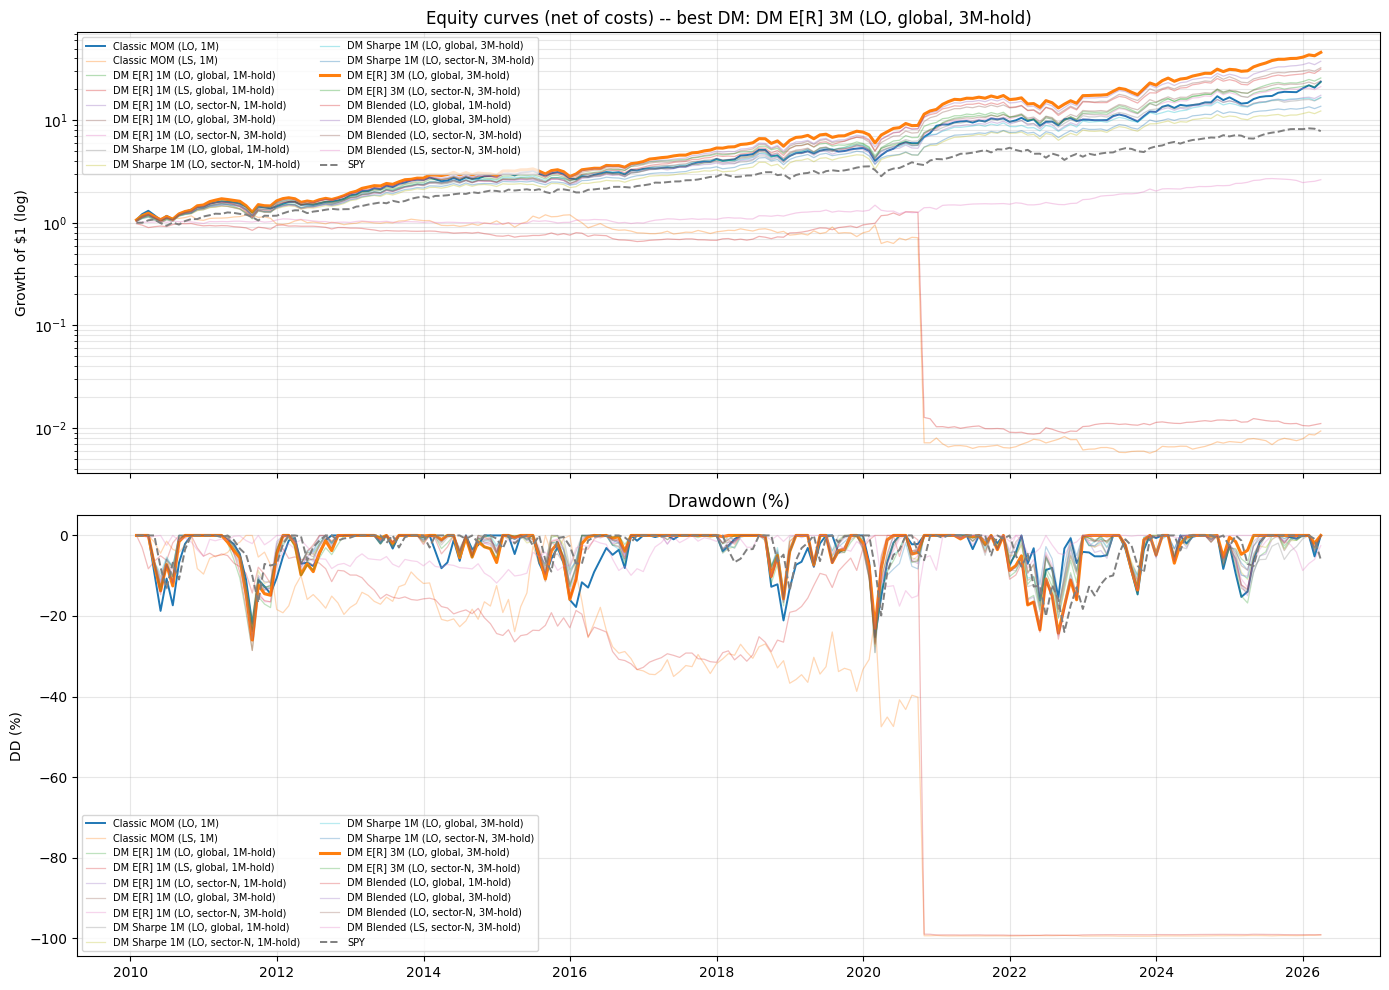

In [12]:
highlight = {best_name, "Classic MOM (LO, 1M)", "SPY"}
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
ax = axes[0]
for name in RESULTS.columns:
    eq = (1 + RESULTS[name].fillna(0)).cumprod()
    lw = 2.2 if name == best_name else (1.4 if name in highlight else 0.9)
    a  = 1.0 if name in highlight else 0.35
    ls = "--" if name == "SPY" else "-"
    ax.plot(eq.index, eq.values, label=name, lw=lw, alpha=a, ls=ls)
ax.set_yscale("log"); ax.grid(True, which="both", alpha=0.3)
ax.set_title(f"Equity curves (net of costs) -- best DM: {best_name}")
ax.set_ylabel("Growth of $1 (log)")
ax.legend(loc="upper left", ncol=2, fontsize=7)

ax2 = axes[1]
for name in RESULTS.columns:
    eq = (1 + RESULTS[name].fillna(0)).cumprod(); dd = eq / eq.cummax() - 1
    lw = 2.2 if name == best_name else (1.4 if name in highlight else 0.9)
    a  = 1.0 if name in highlight else 0.3
    ls = "--" if name == "SPY" else "-"
    ax2.plot(dd.index, dd.values*100, label=name, lw=lw, alpha=a, ls=ls)
ax2.set_title("Drawdown (%)"); ax2.set_ylabel("DD (%)"); ax2.grid(True, alpha=0.3)
ax2.legend(loc="lower left", ncol=2, fontsize=7)
plt.tight_layout(); plt.show()

## 11. Bimodality + calibration + feature importance

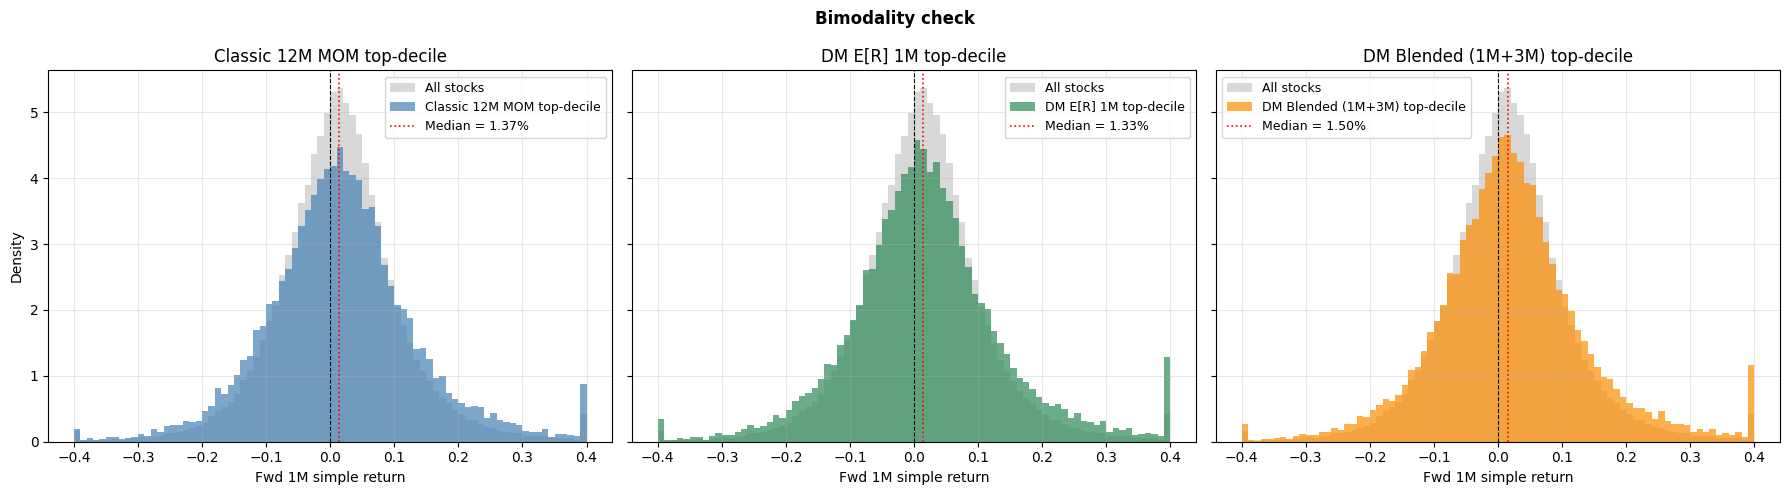


Tail-risk comparison:
  Classic       mean=+1.88%  median=+1.37%  P(r<-10%)=13.3%  P(r>+10%)=19.6%
  DM E[R] 1M    mean=+1.97%  median=+1.33%  P(r<-10%)=12.9%  P(r>+10%)=19.8%
  DM Blended    mean=+2.11%  median=+1.50%  P(r<-10%)=12.1%  P(r>+10%)=19.7%


In [13]:
def top_decile_picks(sig, score_col, top_pct=TOP_PCT):
    def _pick(g):
        n = len(g)
        if n < 20: return pd.Series(dtype=float)
        k = int(np.ceil(n * top_pct))
        return g.nlargest(k, score_col)["fwd_ret_1m"]
    return sig.groupby(level="date").apply(_pick).dropna()

to_simple = lambda s: np.expm1(s)
all_r = SIGNAL["fwd_ret_1m"]
classic_picks = top_decile_picks(SIGNAL, "mom12")
er_picks      = top_decile_picks(SIGNAL, "er_1m")
blended_picks = top_decile_picks(SIGNAL, "blended_score")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
bins = np.linspace(-0.4, 0.4, 81)
for ax, picks, label, color in [
    (axes[0], classic_picks, "Classic 12M MOM top-decile", "steelblue"),
    (axes[1], er_picks,      "DM E[R] 1M top-decile",       "seagreen"),
    (axes[2], blended_picks, "DM Blended (1M+3M) top-decile","darkorange"),
]:
    ax.hist(to_simple(all_r).clip(bins[0], bins[-1]),    bins=bins, density=True, alpha=0.3, color="gray",  label="All stocks")
    ax.hist(to_simple(picks).clip(bins[0], bins[-1]),    bins=bins, density=True, alpha=0.7, color=color, label=label)
    ax.axvline(0, color="black", lw=0.8, ls="--")
    med = to_simple(picks).median()
    ax.axvline(med, color="red", lw=1.2, ls=":", label=f"Median = {med*100:.2f}%")
    ax.set_title(label); ax.set_xlabel("Fwd 1M simple return"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Density")
plt.suptitle("Bimodality check", fontweight="bold"); plt.tight_layout(); plt.show()

print("\nTail-risk comparison:")
for name, picks in [("Classic", classic_picks), ("DM E[R] 1M", er_picks), ("DM Blended", blended_picks)]:
    r = to_simple(picks)
    print(f"  {name:12s}  mean={r.mean()*100:+.2f}%  median={r.median()*100:+.2f}%  "
          f"P(r<-10%)={(r<-0.10).mean()*100:.1f}%  P(r>+10%)={(r>0.10).mean()*100:.1f}%")

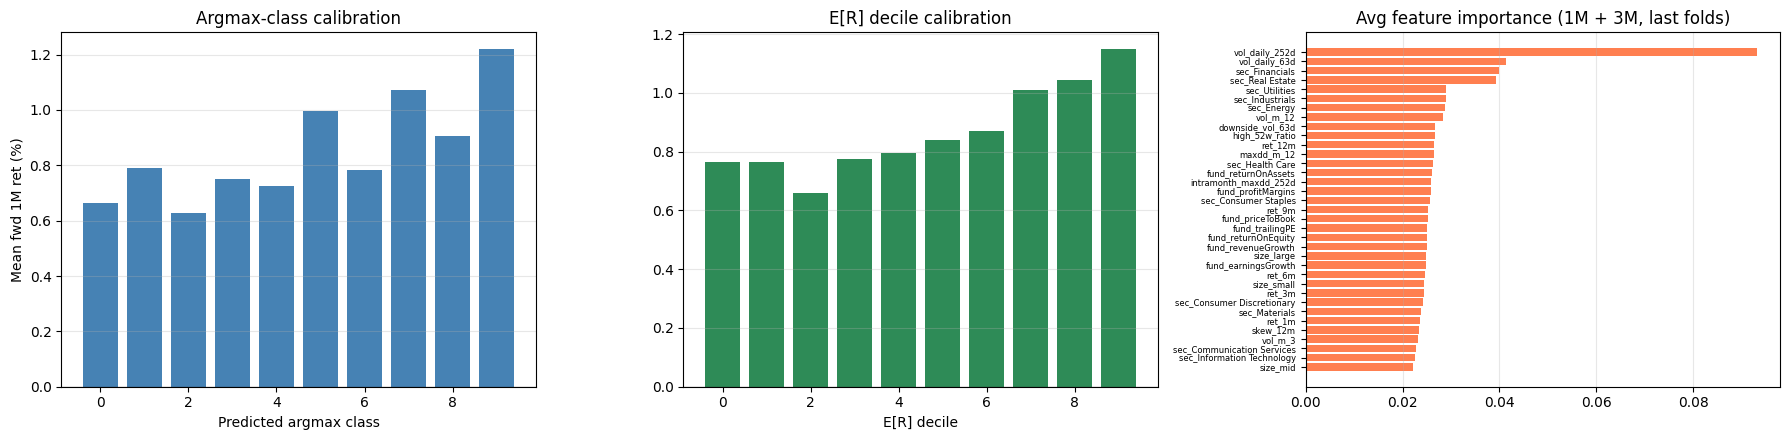


Top 10 features by importance (averaged across horizons):
vol_daily_252d     0.0932
vol_daily_63d      0.0413
sec_Financials     0.0399
sec_Real Estate    0.0393
sec_Utilities      0.0290
sec_Industrials    0.0290
sec_Energy         0.0288
vol_m_12           0.0284
downside_vol_63d   0.0267
high_52w_ratio     0.0266

Total importance share of fundamental features: 17.7%


In [14]:
S1 = SCORED_BY_H[1].copy()
S1["er_decile"] = S1.groupby(level="date")["expected_ret"].transform(
    lambda s: pd.qcut(s.rank(method="first"), N_DECILES, labels=False))
calib_er     = S1.groupby("er_decile")["fwd_ret"].mean().reindex(range(N_DECILES))
calib_argmax = S1.groupby("argmax_cls")["fwd_ret"].mean().reindex(range(N_DECILES))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].bar(calib_argmax.index, calib_argmax*100, color="steelblue")
axes[0].set_title("Argmax-class calibration"); axes[0].set_xlabel("Predicted argmax class")
axes[0].set_ylabel("Mean fwd 1M ret (%)"); axes[0].axhline(0, color="black", lw=0.8); axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(calib_er.index, calib_er*100, color="seagreen")
axes[1].set_title("E[R] decile calibration"); axes[1].set_xlabel("E[R] decile")
axes[1].axhline(0, color="black", lw=0.8); axes[1].grid(True, axis="y", alpha=0.3)

# Feature importance (avg across horizons' last folds)
fi_avg = sum(LAST_FI_BY_H[h] for h in LABEL_HORIZONS) / len(LABEL_HORIZONS)
fi = fi_avg.sort_values(ascending=True)
axes[2].barh(fi.index, fi.values, color="coral")
axes[2].set_title("Avg feature importance (1M + 3M, last folds)")
axes[2].tick_params(axis="y", labelsize=6); axes[2].grid(True, axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

print("\nTop 10 features by importance (averaged across horizons):")
print(fi_avg.sort_values(ascending=False).head(10).round(4).to_string())
fund_usage = fi_avg[[c for c in fi_avg.index if c.startswith('fund_')]].sum()
print(f"\nTotal importance share of fundamental features: {fund_usage*100:.1f}%")

## 12. Live picks -- next-month portfolio, enriched with fundamentals

We use the **best variant from the backtest** to score today's universe, then display fundamentals alongside.

In [15]:
TOP_N_DISPLAY = 20
latest_date = X.index.get_level_values("date").max()
latest_X = X.loc[latest_date]
print(f"Latest feature month: {latest_date.date()}   n_stocks={len(latest_X)}")

# Ensemble-average predictions from the last fold's models for each horizon
def ensemble_proba(X_arr, last_model):
    # We saved only one `last_model` per horizon in LAST_MODEL_BY_H; for live picks that's sufficient
    return last_model.predict_proba(X_arr)

proba_1m = ensemble_proba(latest_X[FEATURE_COLS].values, LAST_MODEL_BY_H[1])
proba_3m = ensemble_proba(latest_X[FEATURE_COLS].values, LAST_MODEL_BY_H[3])
mu_1m    = FOLD_MU_BY_H[1][max(FOLD_MU_BY_H[1].keys())]
mu_3m    = FOLD_MU_BY_H[3][max(FOLD_MU_BY_H[3].keys())]

er_1m_now  = (proba_1m * mu_1m).sum(axis=1)
er_3m_now  = (proba_3m * mu_3m).sum(axis=1)
sigma_1m   = np.sqrt((proba_1m * (mu_1m - er_1m_now[:, None])**2).sum(axis=1))
sharpe_now = np.where(sigma_1m > 1e-6, er_1m_now / sigma_1m, er_1m_now)
# Blend via percentile rank
r1 = pd.Series(er_1m_now).rank(pct=True).values
r3 = pd.Series(er_3m_now).rank(pct=True).values
blend = (r1 + r3) / 2

live = latest_X.copy()
live["er_1m"]        = er_1m_now
live["er_3m"]        = er_3m_now
live["sharpe_1m"]    = sharpe_now
live["blended_score"]= blend
live["sector"]       = live.index.map(lambda s: SECTOR_MAP.get(s, "Unknown"))
# Attach raw (non-z) fundamentals for display
for f in FUND_FIELDS:
    live[f] = live.index.map(lambda s, col=f: FUND[col].get(s) if s in FUND.index else np.nan)

# Decide which score to rank by based on best variant name
if "Blended"  in best_name: rank_col = "blended_score"
elif "Sharpe" in best_name: rank_col = "sharpe_1m"
elif "E[R] 3M" in best_name: rank_col = "er_3m"
else: rank_col = "er_1m"
print(f"Ranking live picks by: {rank_col}")

longs  = live.sort_values(rank_col, ascending=False).head(TOP_N_DISPLAY)
shorts = live.sort_values(rank_col, ascending=True ).head(TOP_N_DISPLAY)

disp_cols = ["sector", "er_1m", "er_3m", "sharpe_1m", "blended_score",
             "trailingPE", "priceToBook", "returnOnAssets", "returnOnEquity", "profitMargins"]

def fmt_table(df):
    out = df[disp_cols].copy()
    for c in ["er_1m", "er_3m"]:           out[c] = (out[c]*100).round(2)
    for c in ["sharpe_1m", "blended_score"]: out[c] = out[c].round(3)
    for c in ["returnOnAssets", "returnOnEquity", "profitMargins"]: out[c] = (out[c]*100).round(1)
    for c in ["trailingPE", "priceToBook"]: out[c] = out[c].round(1)
    return out

print(f"\nTOP {TOP_N_DISPLAY} LONG picks for the month after {latest_date.date()}:\n")
print(fmt_table(longs).to_string())
print(f"\nBOTTOM {TOP_N_DISPLAY} SHORT picks:\n")
print(fmt_table(shorts).to_string())

print("\nLong-side sector exposure:")
print(longs["sector"].value_counts().to_string())

Latest feature month: 2026-04-30   n_stocks=1208


Ranking live picks by: er_3m

TOP 20 LONG picks for the month after 2026-04-30:

                        sector  er_1m   er_3m  sharpe_1m  blended_score  trailingPE  priceToBook  returnOnAssets  returnOnEquity  profitMargins
symbol                                                                                                                                         
LRCX    Information Technology 3.2200 10.3200     0.2910         0.9980     54.8000      33.0000         21.0000         65.6000        30.2000
LITE    Information Technology 0.4400  9.5300     0.0330         0.6560    256.9000      75.4000          0.3000         29.3000        12.0000
WDC     Information Technology 3.7000  9.2300     0.3150         0.9990     35.1000      17.8000          9.1000         41.1000        35.6000
KD      Information Technology 3.0000  9.2100     0.2410         0.9950     13.7000       2.7000          3.8000         19.9000         1.7000
WING    Consumer Discretionary 2.1500  8.3200     0.183

## Wrap-up -- v3 changes delivered

- **Ensemble of 3 seeds** per fold per horizon (predict_proba averaged)
- **Multi-horizon labels** (1M + 3M) with rank-blended combined score
- **Longer holding period** (1M + 3M hold variants; 3M drops turnover ~60-70%)
- **Daily-derived vol features** (63d / 252d realized vol, 63d downside vol, 252d intramonth max-DD)
- **Fundamentals** (trailing PE, P/B, ROA, ROE, profit margin, earnings/revenue growth) as static per-ticker features and displayed with live picks

### Known honest limitations (still)
- **Fundamentals are today's snapshot**, not point-in-time. Used as ticker-constants so leakage is bounded, but look at feature importance: if `fund_*` features dominate, the backtest Sharpe is inflated. Production use would need a PIT fundamentals feed (Sharadar, Compustat, etc.).
- **Universe is today's S&P 1500**. Survivorship bias only partially mitigated by the per-month liquidity filter.
- **Short leg is theoretical** (no borrow costs/availability).
- **Yearly refit** -- monthly refit would be more reactive but ~12x more compute.
- **US-only**. Global joint training from paper v2 is a separate project.

### If Sharpe is still below 1.5
The honest ceiling on monthly momentum-only models is roughly 1.0-1.3 Sharpe on US-only equities without alt data. The paper reports 1.6-2.8 only with richer setups (global joint training, many more features, or neural-net non-linearities). To push above 1.3 from here, realistic moves are:
- **PIT fundamentals** (biggest single lever; replaces the static snapshot)
- **Short-term reversal** as a second-horizon signal (5d / 10d)
- **Calmar-weighted reclassification** (E[R] / historical-max-DD instead of E[R] / σ)
- **Alternative data** -- analyst revisions, short-interest, news sentiment